In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import title

In [36]:
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"

In [37]:
data = pd.read_csv('fake_news_data.csv')

<Axes: xlabel='fake_or_factual'>

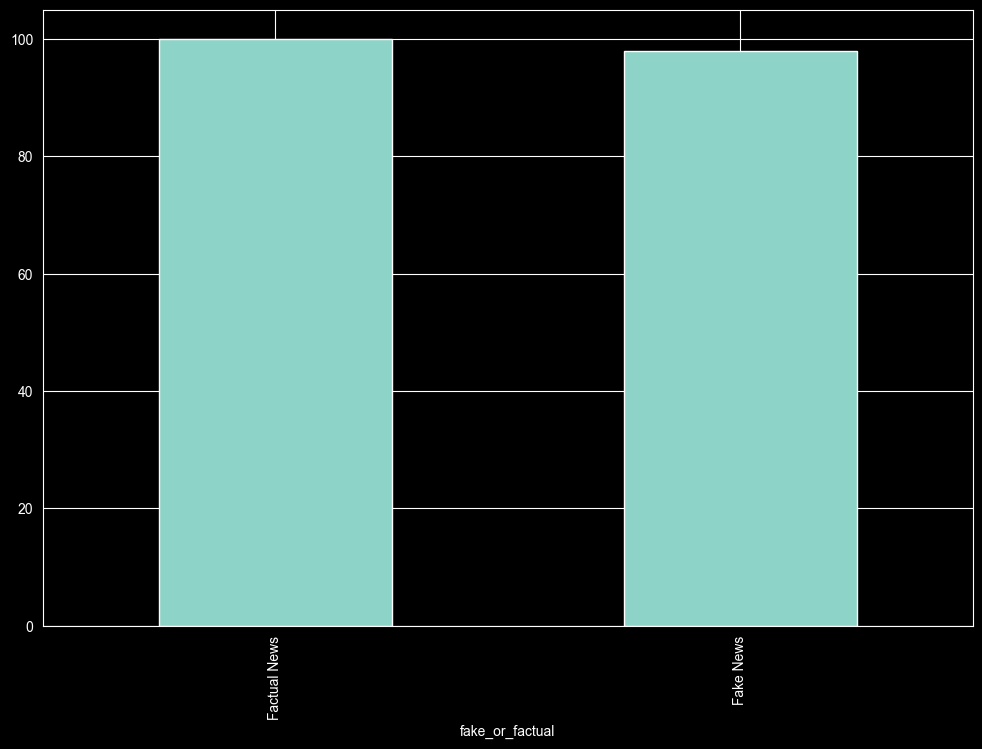

In [38]:
data['fake_or_factual'].value_counts().plot(kind='bar')

In [39]:
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [40]:
nlp = spacy.load('en_core_web_sm')
# split data by fake and factual news
fake_news = data[data['fake_or_factual'] == "Fake News"]
fact_news = data[data['fake_or_factual'] == "Factual News"]
# create spacey documents - use pipe for dataframe
fake_spaceydocs = list(nlp.pipe(fake_news['text']))
fact_spaceydocs = list(nlp.pipe(fact_news['text']))

In [41]:
import numpy as np

In [42]:
columns = ["token", "ner_tag", "pos_tag"]

fake_rows = [(token.text, token.ent_type_ if token.ent_type_ else np.nan, token.pos_) for doc in fake_spaceydocs for token in doc]
fake_tagsdf = pd.DataFrame(fake_rows, columns=columns)

fact_rows = [(token.text, token.ent_type_ if token.ent_type_ else np.nan, token.pos_) for doc in fact_spaceydocs for token in doc]
fact_tagsdf = pd.DataFrame(fact_rows, columns=columns)

In [43]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [44]:
pos_counts_fact = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [45]:
pos_counts_fact

,token,pos_tag,count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
...,...,...,...
2909,crossing,VERB,1
2911,crucial,ADJ,1
2913,cruise,NOUN,1
2914,crusade,NOUN,1


In [46]:
pos_counts_fact.groupby(['pos_tag'])['token'].size().sort_values(ascending=False)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

In [47]:
pos_counts_fake.groupby(['pos_tag']).size().sort_values(ascending=False)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
dtype: int64

In [48]:
pos_counts_fake[pos_counts_fake.pos_tag == "NOUN"].head()

,token,pos_tag,count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52


In [49]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != np.nan].groupby(['token', 'ner_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [50]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag'] != np.nan].groupby(['token', 'ner_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [51]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most common entities in Fake News')]

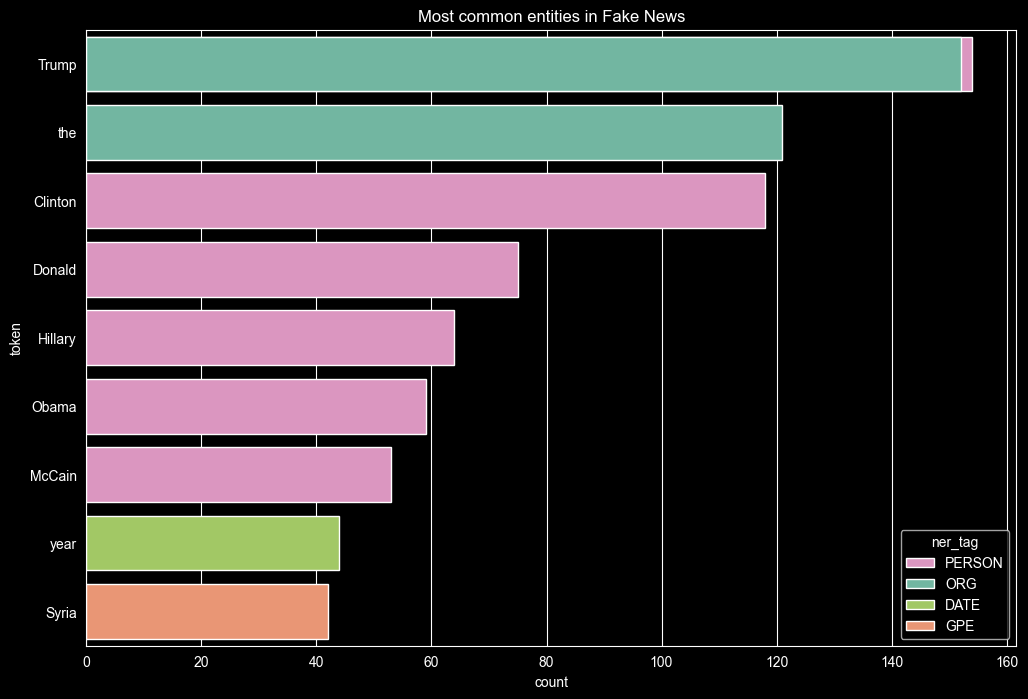

In [52]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[0:10],
    orient = 'h',
    dodge = False
).set(title = "Most common entities in Fake News")

[Text(0.5, 1.0, 'Most common entities in Fact News')]

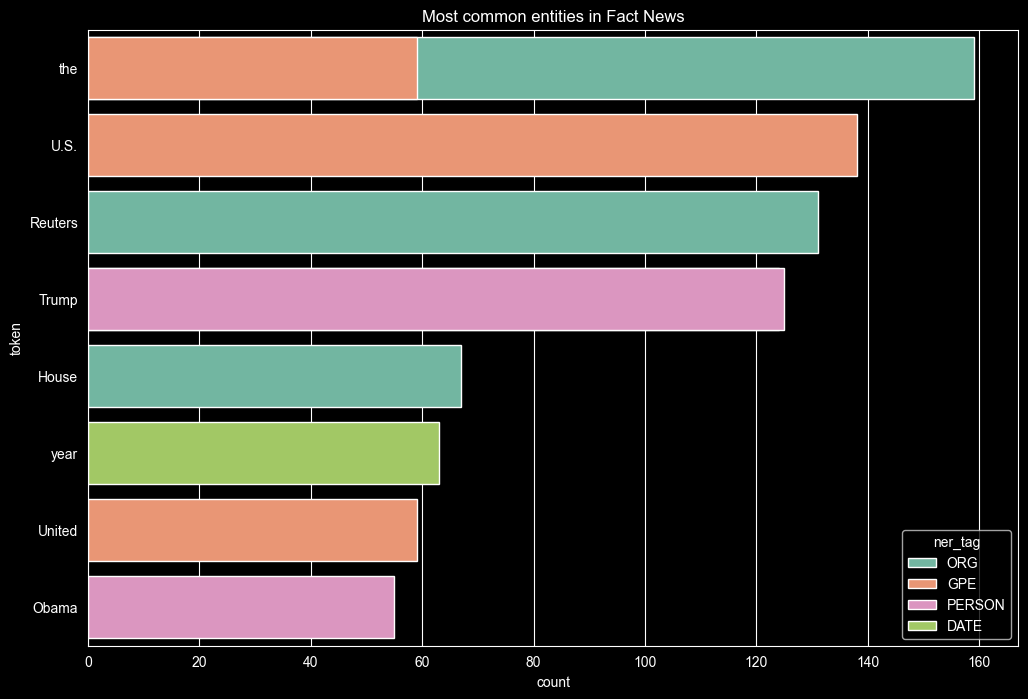

In [53]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[0:10],
    orient = 'h',
    dodge = False
).set(title = "Most common entities in Fact News")

In [54]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [55]:
data['text_clean'] = data['text'].str.replace(r"^[^-]*-\s*", "", regex=True)

In [56]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,year-old Oscar-winning actress described meeti...
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,Buried in Trump s bonkers interview with New Y...
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"Women make up over 50 percent of this country,..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,U.S. Defense Secretary Jim Mattis said on Mond...
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,Northern Ireland s political parties are rapid...


In [57]:
data['text_clean'] = data['text_clean'].str.lower()

In [58]:
data['text_clean'] = data['text_clean'].str.replace(r"([^\w\s])", "", regex=True)

In [59]:
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [60]:
data['text_clean'] = data['text_clean'].apply(lambda text: ' '.join([word for word in text.split() if word not in en_stopwords]))

In [61]:
data['text_clean'] = data['text_clean'].apply(lambda text: word_tokenize(text))

In [62]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(lambda x: [lemmatizer.lemmatize(token) for token in x])

In [63]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [64]:
unigrams = data['text_clean'].explode().value_counts().reset_index()

In [65]:
unigrams.head()

,text_clean,count
0,said,560
1,trump,520
2,u,255
3,state,250
4,president,226


In [66]:
unigrams.columns = ['token', 'count']

/var/folders/xj/klgwqm4j1q17_fxjszznd2640000gn/T/ipykernel_86722/1940728173.py:1: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most common unigrams after Preprocessing')]

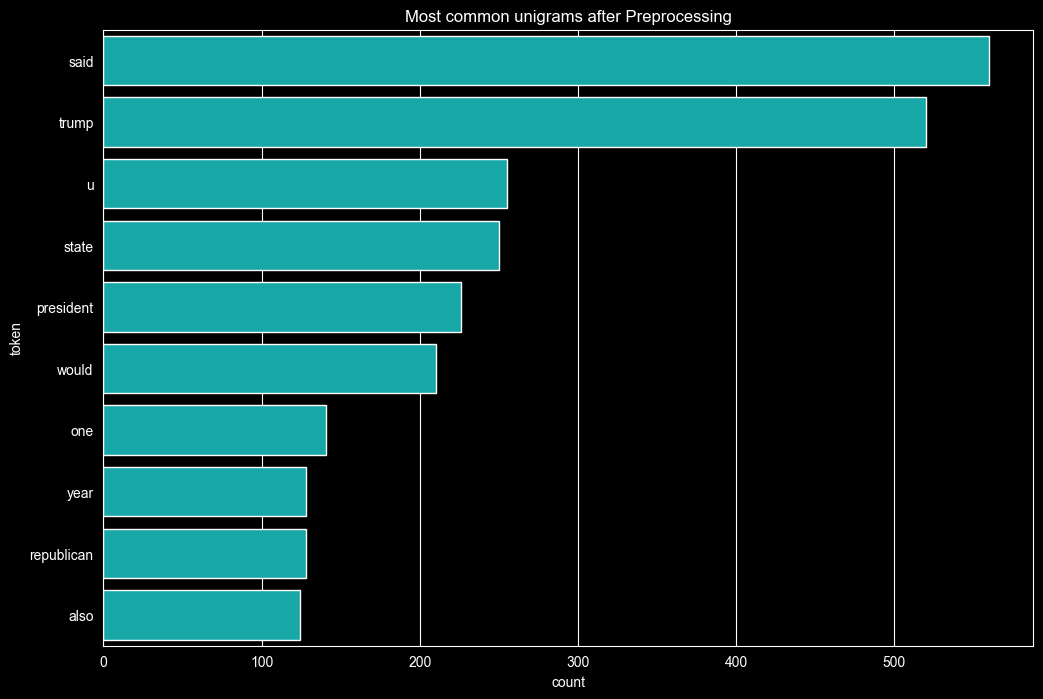

In [67]:
sns.barplot(
    x = 'count',
    y = 'token',
    data = unigrams[0:10],
    hue = 'token',
    legend=False,
    orient = 'h',
    palette=[default_plot_colour]
).set(title = 'Most common unigrams after Preprocessing')

In [68]:
row_bigrams = data['text_clean'].apply(lambda x: list(nltk.ngrams(x, 2)))

In [69]:
bigrams = row_bigrams.explode().value_counts().reset_index()
bigrams.columns = ['bigram', 'count']
bigrams.head()

,bigram,count
0,"(donald, trump)",92
1,"(united, state)",80
2,"(white, house)",72
3,"(president, donald)",42
4,"(hillary, clinton)",31


/var/folders/xj/klgwqm4j1q17_fxjszznd2640000gn/T/ipykernel_86722/2664551418.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most common bigrams after Preprocessing')]

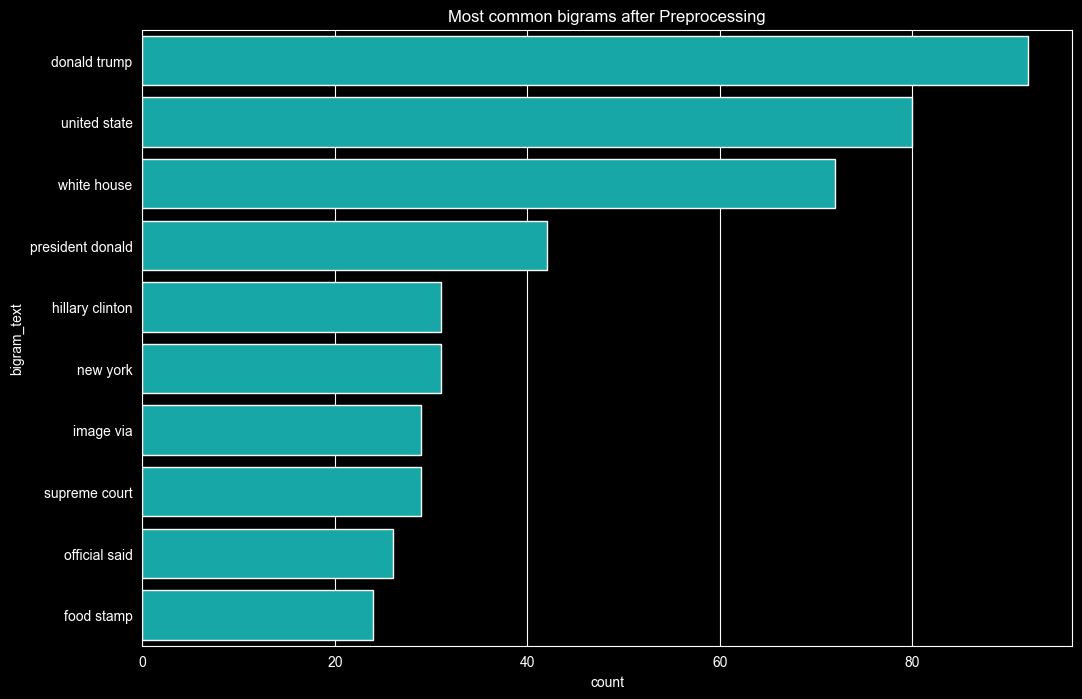

In [70]:
bigrams['bigram_text'] = bigrams['bigram'].apply(lambda x: ' '.join(x))

sns.barplot(
    x = 'count',
    y = 'bigram_text',
    data=bigrams[0:10],
    hue = 'bigram_text',
    palette=[default_plot_colour],
    orient = 'h',
).set(title = 'Most common bigrams after Preprocessing')

In [71]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [72]:
vader_sentiment = SentimentIntensityAnalyzer()
data['vader_sentiment_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [73]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

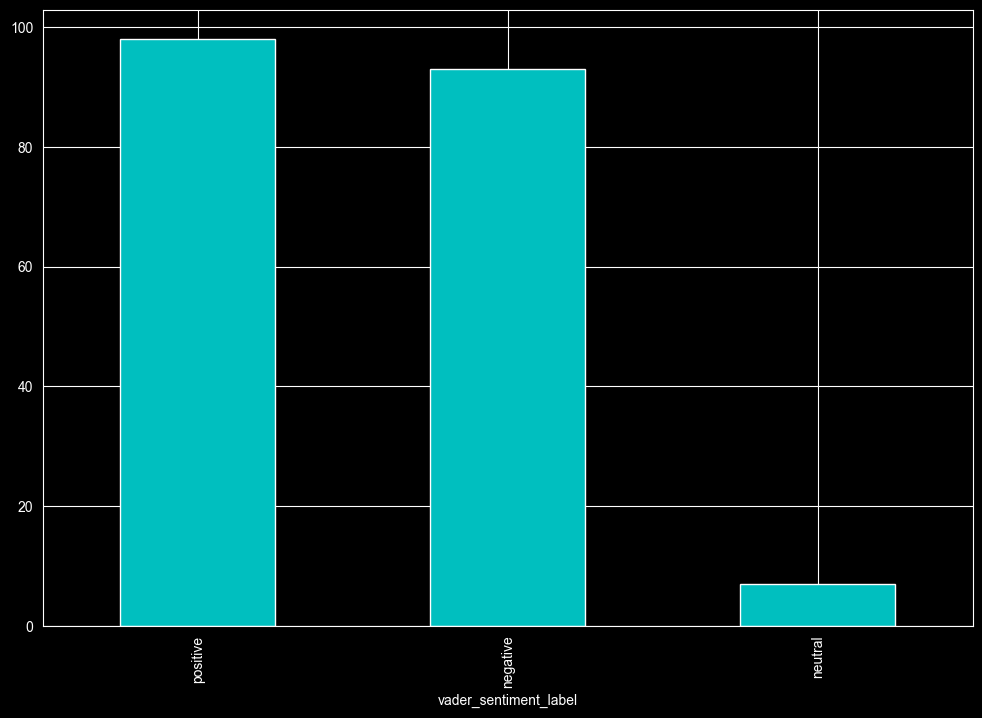

In [74]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/var/folders/xj/klgwqm4j1q17_fxjszznd2640000gn/T/ipykernel_86722/2458993325.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by news type')]

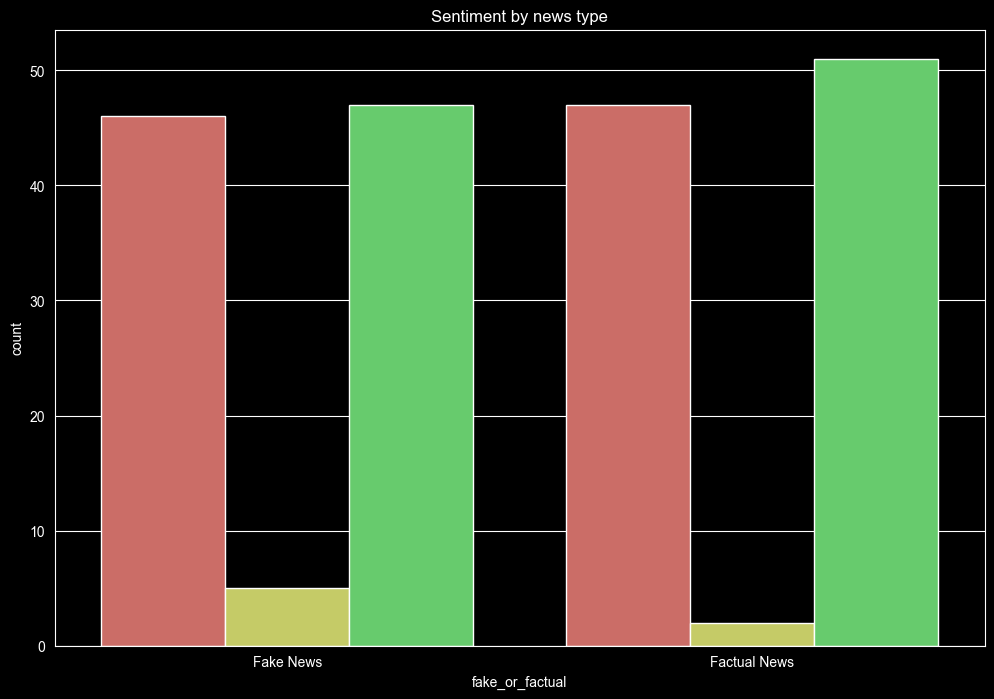

In [75]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    data=data,
    palette=sns.color_palette("hls"),
    legend = False
).set(title = 'Sentiment by news type')

In [76]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [77]:
fake_news_clean = data[data['fake_or_factual'] == 'Fake News']['text_clean'].reset_index(drop=True)
fake_news_clean.head()

0    [yearold, oscarwinning, actress, described, me...
1    [buried, trump, bonkers, interview, new, york,...
2    [woman, make, 50, percent, country, grossly, u...
3    [58, resolution, consider, move, week, fox, ne...
4    [inneck, race, must, pretty, antsy, though, un...
Name: text_clean, dtype: object

In [78]:
dictionary_fake = corpora.Dictionary(fake_news_clean)
doc_term_fake = [dictionary_fake.doc2bow(token_list) for token_list in fake_news_clean]

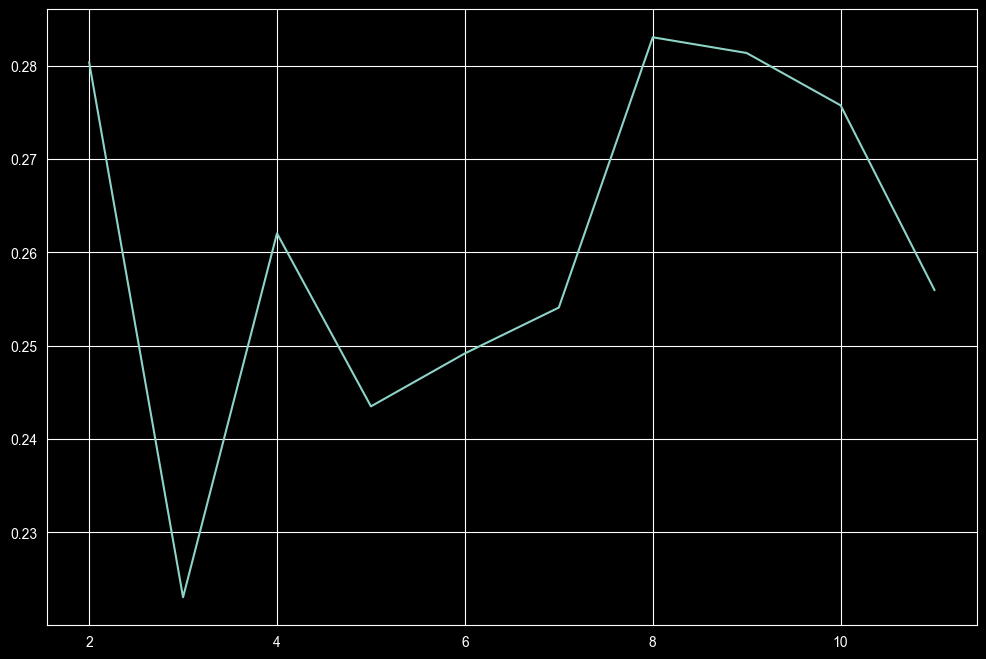

In [79]:
coherence_scores = []
models = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics + 1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=num_topics_i, id2word=dictionary_fake)
    models.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_clean, dictionary=dictionary_fake, coherence='c_v')
    coherence_scores.append(coherence_model.get_coherence())

plt.plot(range(min_topics, max_topics + 1), coherence_scores)
plt.show()

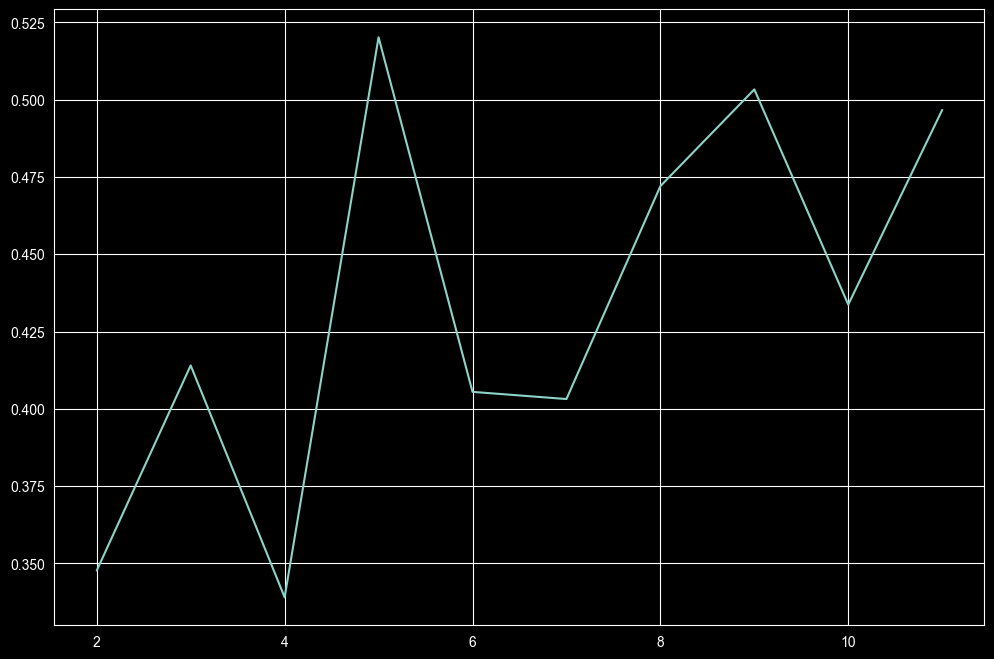

In [80]:
tfidf_transformer = TfidfModel(corpus=doc_term_fake, normalize=True)
tfidf_corpus = tfidf_transformer[doc_term_fake]

coherence_scores = []
models = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics + 1):
    model = LsiModel(tfidf_corpus, num_topics=num_topics_i, id2word=dictionary_fake, random_seed=0)
    models.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_clean, dictionary=dictionary_fake, coherence='c_v')
    coherence_scores.append(coherence_model.get_coherence())

plt.plot(range(min_topics, max_topics + 1), coherence_scores)

In [82]:
lsa_fake = LsiModel(tfidf_corpus, num_topics=5, id2word=dictionary_fake)
lsa_fake.print_topics()

[(0,
  '0.218*"trump" + 0.135*"clinton" + 0.094*"woman" + 0.087*"president" + 0.086*"republican" + 0.085*"obama" + 0.084*"party" + 0.083*"school" + 0.081*"said" + 0.079*"time"'),
 (1,
  '-0.299*"boiler" + -0.253*"room" + -0.250*"acr" + -0.186*"jay" + -0.185*"animal" + -0.176*"episode" + -0.147*"analysis" + -0.122*"dyer" + -0.119*"savant" + -0.119*"moralist"'),
 (2,
  '-0.219*"school" + 0.195*"clinton" + 0.163*"conference" + -0.151*"county" + -0.137*"student" + 0.120*"press" + 0.116*"trump" + 0.112*"hillary" + -0.101*"love" + 0.095*"email"'),
 (3,
  '0.375*"flynn" + 0.151*"russian" + 0.111*"email" + 0.109*"30" + 0.101*"department" + 0.100*"information" + 0.100*"nana" + 0.099*"official" + 0.098*"mccain" + -0.096*"trump"'),
 (4,
  '-0.235*"trump" + -0.223*"flynn" + -0.166*"conference" + 0.165*"clinton" + 0.153*"dnc" + 0.151*"sander" + 0.127*"email" + -0.111*"press" + 0.109*"rich" + -0.084*"tax"')]

In [94]:
X = [' '.join(map(str, l)) for l in data['text_clean']]
Y = data['fake_or_factual']
countvec = CountVectorizer()
bag_of_words = countvec.fit_transform(X)
# bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns = countvec.get_feature_names_out())

In [95]:
x_train, x_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size=0.3)

In [96]:
lr = LogisticRegression(random_state=0).fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

In [97]:
accuracy_score(y_pred_lr, y_test)

0.9166666666666666

In [98]:
svm = SGDClassifier().fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
accuracy_score(y_pred_svm, y_test)

0.9

In [99]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       0.90      0.90      0.90        29
   Fake News       0.90      0.90      0.90        31

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

